# 1️⃣ Introduction

Artificial Intelligence is rapidly changing the way students study, learn, and perform academically. This dataset captures AI usage patterns, study habits, and their impact on grades and satisfaction.  
The dataset is synthetic but closely resembles real student behavior and is perfect for educational and analytical exploration.


# 2️⃣ Dataset Overview

In [1]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/guriya79/how-ai-is-changing-student-life/AI_Student_Life_Pakistan_2026.csv')

In [2]:
df.head()

,Student_ID,Age,Gender,Education_Level,City,AI_Tool_Used,Daily_Usage_Hours,Purpose,Impact_on_Grades,Satisfaction_Level
0,1,15,Female,School,Lahore,ChatGPT,0.8,Writing,Slight Decline,Low
1,2,15,Female,College,Multan,Copilot,1.6,Learning,No Change,High
2,3,16,Female,College,Multan,ChatGPT,1.8,Research,Improved,Low
3,4,22,Male,University,Karachi,ChatGPT,4.2,Learning,Improved,High
4,5,16,Male,School,Multan,ChatGPT,1.8,Coding,Improved,Medium


In [3]:
df.shape

(100, 10)

# Check missing values

In [4]:
df.isnull().sum()

Student_ID            0
Age                   0
Gender                0
Education_Level       0
City                  0
AI_Tool_Used          0
Daily_Usage_Hours     0
Purpose               0
Impact_on_Grades      0
Satisfaction_Level    0
dtype: int64

# 3️⃣ Summary Statistics

In [5]:
df.describe()

,Student_ID,Age,Daily_Usage_Hours
count,100.000000,100.000000,100.000000
mean,50.500000,19.380000,3.064000
std,29.011492,3.296095,1.564862
min,1.000000,15.000000,0.500000
25%,25.750000,16.000000,1.800000
50%,50.500000,19.000000,3.200000
75%,75.250000,22.000000,4.300000
max,100.000000,25.000000,5.900000


In [6]:
for col in ['Gender','Education_Level','AI_Tool_Used','Purpose','Impact_on_Grades','Satisfaction_Level']:
    print(f"{col} value counts:\n", df[col].value_counts(), "\n")

Gender value counts:
 Gender
Female    52
Male      48
Name: count, dtype: int64 

Education_Level value counts:
 Education_Level
School        46
College       29
University    25
Name: count, dtype: int64 

AI_Tool_Used value counts:
 AI_Tool_Used
Grammarly    24
Gemini       24
ChatGPT      20
Copilot      17
Notion AI    15
Name: count, dtype: int64 

Purpose value counts:
 Purpose
Homework    24
Research    21
Learning    21
Coding      20
Writing     14
Name: count, dtype: int64 

Impact_on_Grades value counts:
 Impact_on_Grades
Improved          39
No Change         34
Slight Decline    27
Name: count, dtype: int64 

Satisfaction_Level value counts:
 Satisfaction_Level
Low       38
Medium    32
High      30
Name: count, dtype: int64 



In [7]:
import warnings
warnings.filterwarnings('ignore')

# 4️⃣ Visualizations

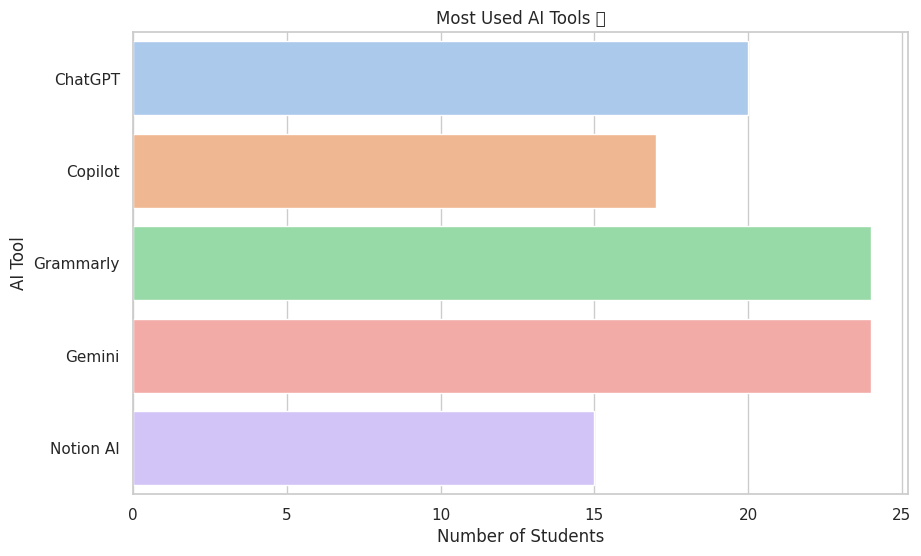

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='AI_Tool_Used', palette='pastel')
plt.title("Most Used AI Tools 📊")
plt.xlabel("Number of Students")
plt.ylabel("AI Tool")
plt.show()

# Bar Plot

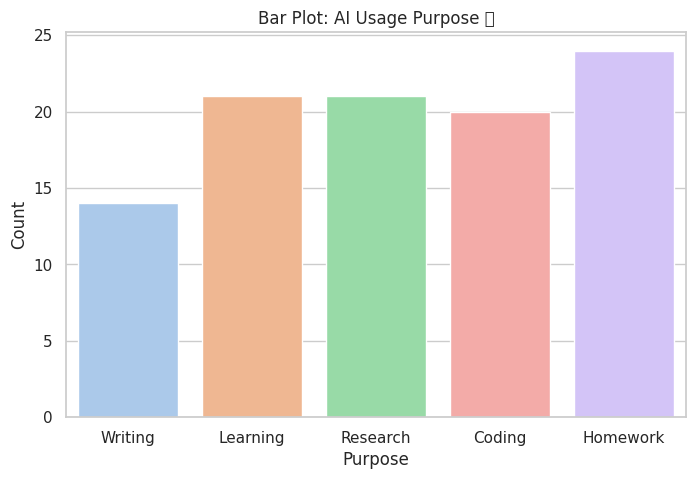

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Purpose', palette='pastel')
plt.title("Bar Plot: AI Usage Purpose 📊")
plt.xlabel("Purpose")
plt.ylabel("Count")
plt.show()

#  Box Plot

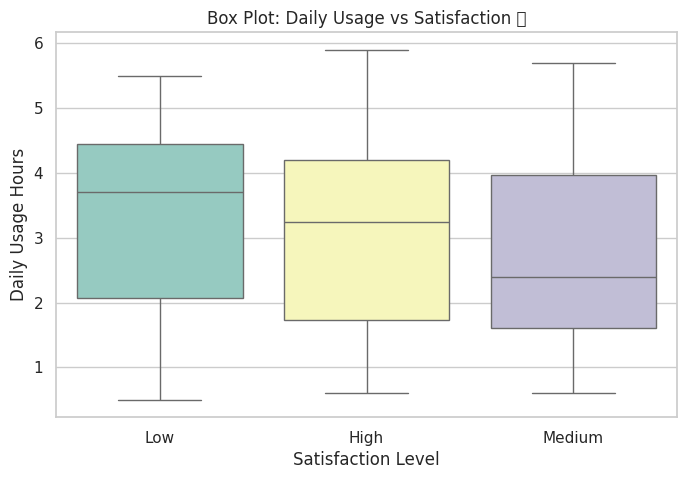

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Satisfaction_Level', y='Daily_Usage_Hours', palette='Set3')
plt.title("Box Plot: Daily Usage vs Satisfaction 📦")
plt.xlabel("Satisfaction Level")
plt.ylabel("Daily Usage Hours")
plt.show()


# Line Plot

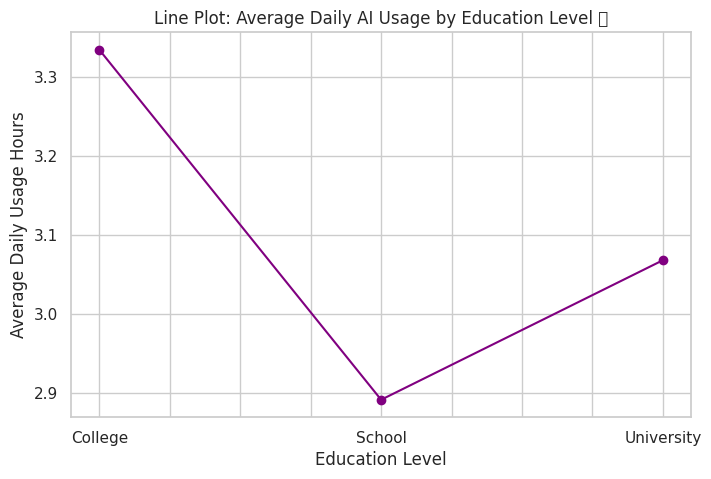

In [11]:
plt.figure(figsize=(8,5))
df.groupby('Education_Level')['Daily_Usage_Hours'].mean().plot(marker='o', linestyle='-', color='purple')
plt.title("Line Plot: Average Daily AI Usage by Education Level 📈")
plt.xlabel("Education Level")
plt.ylabel("Average Daily Usage Hours")
plt.show()


#  Heatmap

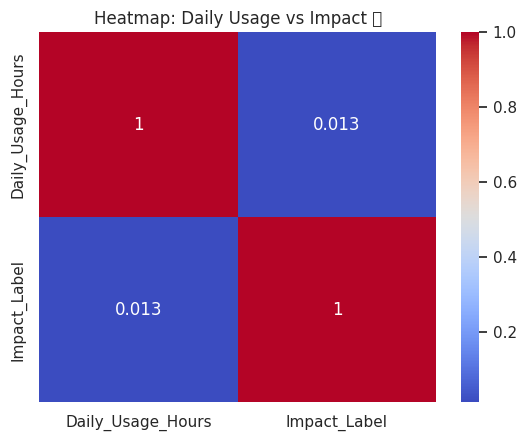

In [12]:
sns.heatmap(df[['Daily_Usage_Hours']].join(df['Impact_on_Grades'].map({'Improved':2,'No Change':1,'Slight Decline':0}).rename('Impact_Label')).corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap: Daily Usage vs Impact 💡')
plt.show()

# Scatter Plot

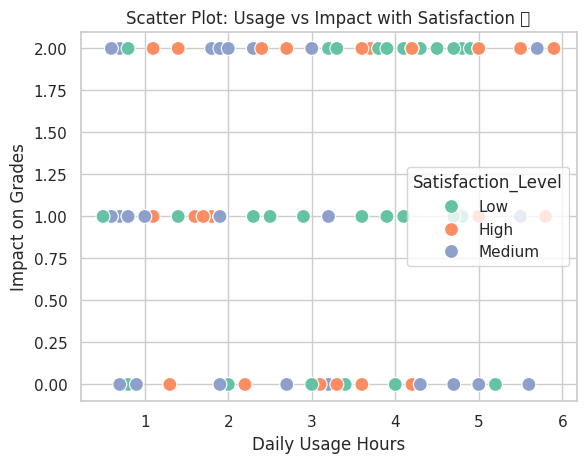

In [13]:
sns.scatterplot(
    data=df.assign(Impact_Label=df['Impact_on_Grades'].map({'Improved':2,'No Change':1,'Slight Decline':0})),
    x='Daily_Usage_Hours',
    y='Impact_Label',
    hue='Satisfaction_Level',
    palette='Set2',
    s=100
)
plt.title("Scatter Plot: Usage vs Impact with Satisfaction ✨")
plt.xlabel("Daily Usage Hours")
plt.ylabel("Impact on Grades")
plt.show()

# Pair Plot

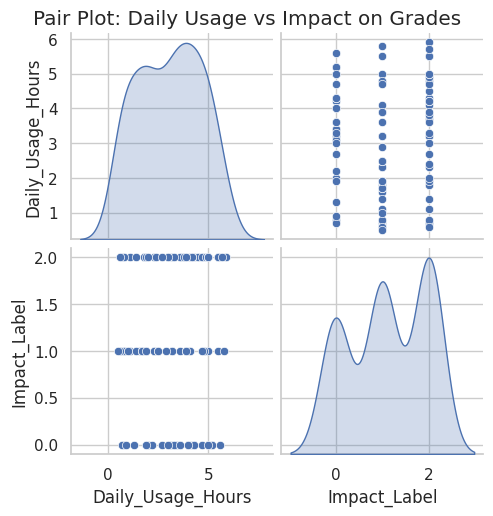

In [14]:
sns.pairplot(
    df.assign(Impact_Label=df['Impact_on_Grades'].map({'Improved':2,'No Change':1,'Slight Decline':0})),
    vars=['Daily_Usage_Hours','Impact_Label'],
    kind='scatter',
    diag_kind='kde'
)
plt.suptitle("Pair Plot: Daily Usage vs Impact on Grades", y=1.02)
plt.show()

# Count Plot

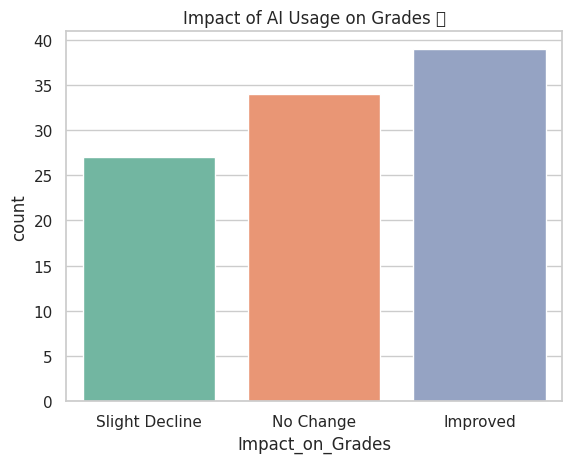

In [15]:
sns.countplot(data=df, x='Impact_on_Grades', palette='Set2')
plt.title("Impact of AI Usage on Grades 🔥")
plt.show()